# 02 — GNN Training & Evaluation

This notebook trains a **GraphSAGE** model on the EU AI Act knowledge graph using **self-supervised contrastive learning** (InfoNCE loss).

## Contents
1. Setup & Load Graph
2. Data Inspection
3. Edge Splitting (Train / Val / Test)
4. Model Initialisation
5. Training Loop
6. Training Curves
7. Embedding Analysis
8. Nearest-Neighbour Retrieval Demo
9. Baseline Comparison
10. Save Final Embeddings

---
## 1. Setup & Load Graph

In [139]:
import random
from typing import Optional

import numpy as np
import torch
import torch.nn.functional as F
import yaml


def load_config(config_path: str = "configs/config.yaml") -> dict:
    with open(config_path, "r") as f:
        return yaml.safe_load(f)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def split_edges(
    edge_index: torch.Tensor,
    edge_types=None,
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
) -> dict:
    num_edges = edge_index.size(1)
    perm = torch.randperm(num_edges)

    train_end = int(num_edges * train_ratio)
    val_end = int(num_edges * (train_ratio + val_ratio))

    train_idx = perm[:train_end]
    val_idx = perm[train_end:val_end]
    test_idx = perm[val_end:]

    out = {
        "train": edge_index[:, train_idx],
        "val": edge_index[:, val_idx],
        "test": edge_index[:, test_idx],
    }

    if edge_types is not None:
        out["train_edge_type"] = edge_types[train_idx]
        out["val_edge_type"] = edge_types[val_idx]
        out["test_edge_type"] = edge_types[test_idx]

    return out


def sample_contrastive_pairs(
    edge_index: torch.Tensor,
    num_nodes: int,
    num_negatives: int = 5,
    forbid_adj: Optional[list[set[int]]] = None,
):
    anchors = edge_index[0]
    positives = edge_index[1]

    num_pairs = anchors.size(0)
    negatives = torch.empty((num_pairs, num_negatives), dtype=torch.long)

    if forbid_adj is None:
        forbid_adj = [set() for _ in range(num_nodes)]

    for i in range(num_pairs):
        a = int(anchors[i].item())
        forbidden = set(forbid_adj[a]) if a < len(forbid_adj) else set()
        forbidden.add(a)

        for j in range(num_negatives):
            neg = torch.randint(0, num_nodes, (1,)).item()
            tries = 0
            while neg in forbidden and tries < 25:
                neg = torch.randint(0, num_nodes, (1,)).item()
                tries += 1
            negatives[i, j] = neg

    return anchors, positives, negatives


def infonce_loss(
    anchor_emb: torch.Tensor,
    positive_emb: torch.Tensor,
    negative_embs: torch.Tensor,
    temperature: float = 0.07,
) -> torch.Tensor:
    pos_sim = F.cosine_similarity(anchor_emb, positive_emb, dim=-1) / temperature
    anchor_expanded = anchor_emb.unsqueeze(1)
    neg_sim = F.cosine_similarity(anchor_expanded, negative_embs, dim=-1) / temperature
    logits = torch.cat([pos_sim.unsqueeze(1), neg_sim], dim=1)
    labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
    return F.cross_entropy(logits, labels)

import sys
sys.path.insert(0, '..')

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import yaml

from src.gnn.models import get_model, GraphSAGEEncoder

# Style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

# Config
config = load_config('../configs/config.yaml')

# Seed
set_seed(config['project']['seed'])

# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device: {device}')
print('Setup complete ✓')


Device: cpu
Setup complete ✓


In [140]:
import random
from typing import Optional

import numpy as np
import torch
import torch.nn.functional as F
import yaml


def load_config(config_path: str = "configs/config.yaml") -> dict:
    with open(config_path, "r") as f:
        return yaml.safe_load(f)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def split_edges(
    edge_index: torch.Tensor,
    edge_types=None,
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
) -> dict:
    num_edges = edge_index.size(1)
    perm = torch.randperm(num_edges)

    train_end = int(num_edges * train_ratio)
    val_end = int(num_edges * (train_ratio + val_ratio))

    train_idx = perm[:train_end]
    val_idx = perm[train_end:val_end]
    test_idx = perm[val_end:]

    out = {
        "train": edge_index[:, train_idx],
        "val": edge_index[:, val_idx],
        "test": edge_index[:, test_idx],
    }

    if edge_types is not None:
        out["train_edge_type"] = edge_types[train_idx]
        out["val_edge_type"] = edge_types[val_idx]
        out["test_edge_type"] = edge_types[test_idx]

    return out


def sample_contrastive_pairs(
    edge_index: torch.Tensor,
    num_nodes: int,
    num_negatives: int = 5,
    forbid_adj: Optional[list[set[int]]] = None,
):
    anchors = edge_index[0]
    positives = edge_index[1]

    num_pairs = anchors.size(0)
    negatives = torch.empty((num_pairs, num_negatives), dtype=torch.long)

    if forbid_adj is None:
        forbid_adj = [set() for _ in range(num_nodes)]

    for i in range(num_pairs):
        a = int(anchors[i].item())
        forbidden = set(forbid_adj[a]) if a < len(forbid_adj) else set()
        forbidden.add(a)

        for j in range(num_negatives):
            neg = torch.randint(0, num_nodes, (1,)).item()
            tries = 0
            while neg in forbidden and tries < 25:
                neg = torch.randint(0, num_nodes, (1,)).item()
                tries += 1
            negatives[i, j] = neg

    return anchors, positives, negatives


def infonce_loss(
    anchor_emb: torch.Tensor,
    positive_emb: torch.Tensor,
    negative_embs: torch.Tensor,
    temperature: float = 0.07,
) -> torch.Tensor:
    pos_sim = F.cosine_similarity(anchor_emb, positive_emb, dim=-1) / temperature
    anchor_expanded = anchor_emb.unsqueeze(1)
    neg_sim = F.cosine_similarity(anchor_expanded, negative_embs, dim=-1) / temperature
    logits = torch.cat([pos_sim.unsqueeze(1), neg_sim], dim=1)
    labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
    return F.cross_entropy(logits, labels)


In [141]:
# Load graph
from pathlib import Path


def _resolve_path(*candidates):
    for candidate in candidates:
        if not candidate:
            continue

        p = Path(candidate)
        if p.exists():
            return p

        alt = Path('..') / p
        if alt.exists():
            return alt

        alt2 = Path('notebooks') / p
        if alt2.exists():
            return alt2

    return None


def _normalize_node_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """Make nodes dataframe columns resilient across branches."""
    df = df.copy()

    if 'kind' in df.columns and 'type' not in df.columns:
        df = df.rename(columns={'kind': 'type'})
    elif 'node_type' in df.columns and 'type' not in df.columns:
        df = df.rename(columns={'node_type': 'type'})

    if 'type' not in df.columns:
        df['type'] = 'unknown'
    df['type'] = df['type'].fillna('unknown').astype(str).str.lower()

    if 'node_id' not in df.columns and 'id' in df.columns:
        df = df.rename(columns={'id': 'node_id'})
    if 'node_id' not in df.columns:
        df['node_id'] = [f'node_{i}' for i in range(len(df))]

    if 'title' not in df.columns:
        df['title'] = ''
    df['title'] = df['title'].fillna('').astype(str)

    if 'text' in df.columns:
        missing_title = df['title'].str.strip() == ''
        df.loc[missing_title, 'title'] = df.loc[missing_title, 'text'].str[:120].fillna('')

    if 'chapter' not in df.columns:
        df['chapter'] = ''

    df['chapter'] = df['chapter'].fillna('').astype(str)

    unknown_chapter = (df['chapter'].str.strip() == '')
    if unknown_chapter.any():
        inferred = []
        for node_id in df.loc[unknown_chapter, 'node_id'].astype(str):
            nid = node_id.lower()
            if nid.startswith('article'):
                suffix = node_id.split(' ', 1)[1] if ' ' in node_id else node_id
                inferred.append(suffix.split('(')[0].strip() or 'article')
            elif nid.startswith('annex'):
                inferred.append('ANNEX')
            else:
                inferred.append('OTHER')
        df.loc[unknown_chapter, 'chapter'] = inferred

    return df


graph_rel = config['paths']['graph_object']
graph_candidates = [
    graph_rel,
    f"../{graph_rel}",
    Path('..') / graph_rel,
]
graph_path = _resolve_path(*graph_candidates)
if graph_path is None:
    raise FileNotFoundError(f"Graph object not found. Tried: {graph_candidates}")

data = torch.load(graph_path, weights_only=False)

nodes_rel = config['paths']['nodes_csv']
edges_rel = config['paths']['edges_csv']
nodes_path = _resolve_path(nodes_rel, f"../{nodes_rel}", Path('..') / nodes_rel)
edges_path = _resolve_path(edges_rel, f"../{edges_rel}", Path('..') / edges_rel)
if nodes_path is None or edges_path is None:
    raise FileNotFoundError('Could not resolve nodes/edges metadata paths from config')

nodes_df = pd.read_csv(nodes_path)
edges_df = pd.read_csv(edges_path)

nodes_df = _normalize_node_metadata(nodes_df)

if len(nodes_df) != data.num_nodes:
    n = min(len(nodes_df), data.num_nodes)
    print(f'⚠️  Metadata size ({len(nodes_df)}) != graph nodes ({data.num_nodes}); aligning to first {n}.')
    nodes_df = nodes_df.iloc[:n].reset_index(drop=True)
    if hasattr(data, 'num_nodes') and n < data.num_nodes:
        pass

print(f'Graph loaded ✓')
print(f'  Graph path:  {graph_path}')
print(f'  Nodes:       {data.num_nodes}')
print(f'  Edges:       {data.num_edges}')
print(f'  Features:    {data.x.shape}')
print(f'  Edge types:  {data.edge_type_mapping}')


Graph loaded ✓
  Graph path:  ../data/graphs/eu_ai_act_graph.pt
  Nodes:       974
  Edges:       3873
  Features:    torch.Size([974, 391])
  Edge types:  {'contains': 0, 'part_of': 1, 'refers_to': 2, 'uses_term': 3}


---
## 2. Data Inspection

In [142]:
# Feature statistics
x_np = data.x.numpy()
print(f'Feature matrix shape: {x_np.shape}')
print(f'Feature range:        [{x_np.min():.4f}, {x_np.max():.4f}]')
print(f'Feature mean:         {x_np.mean():.4f}')
print(f'Feature std:          {x_np.std():.4f}')
print(f'Any NaNs:             {np.isnan(x_np).any()}')
print(f'Any Infs:             {np.isinf(x_np).any()}')

# Edge type distribution
print(f'\nEdge type distribution:')
edge_types_tensor = data.edge_type
inv_type_map = {v: k for k, v in data.edge_type_mapping.items()}
for idx in sorted(inv_type_map.keys()):
    count = (edge_types_tensor == idx).sum().item()
    print(f'  {inv_type_map[idx]:15s} → {count}')

Feature matrix shape: (974, 391)
Feature range:        [-0.2184, 1.0000]
Feature mean:         0.0023
Feature std:          0.0716
Any NaNs:             False
Any Infs:             False

Edge type distribution:
  contains        → 666
  part_of         → 666
  refers_to       → 811
  uses_term       → 1730


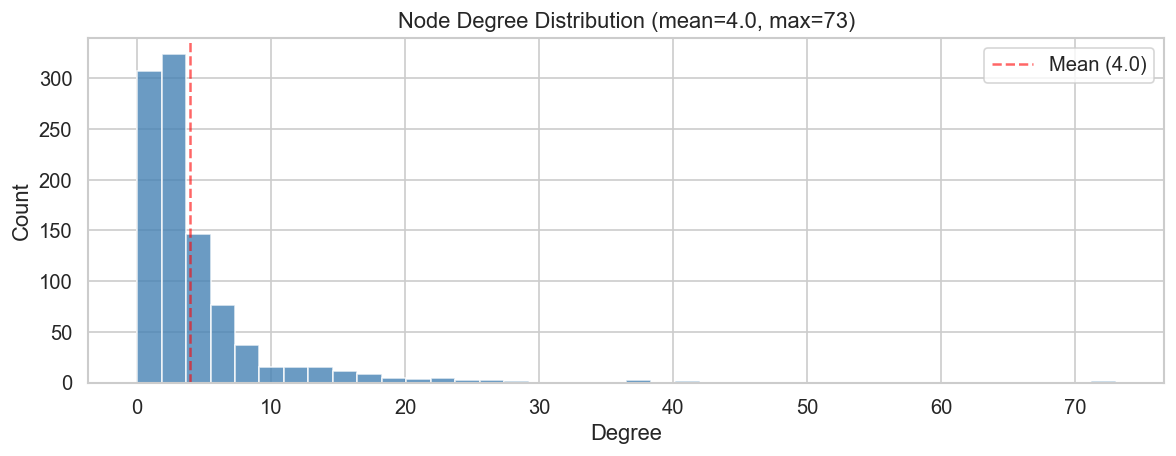

In [143]:
# Degree distribution of the PyG graph
from torch_geometric.utils import degree

deg = degree(data.edge_index[0], num_nodes=data.num_nodes)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(deg.numpy(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Degree')
ax.set_ylabel('Count')
ax.set_title(f'Node Degree Distribution (mean={deg.mean():.1f}, max={deg.max():.0f})')
ax.axvline(deg.mean(), color='red', linestyle='--', alpha=0.6, label=f'Mean ({deg.mean():.1f})')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Edge Splitting (Train / Val / Test)

In [144]:
# Split edges
edge_splits = split_edges(
    data.edge_index,
    train_ratio=config['training']['train_ratio'],
    val_ratio=config['training']['val_ratio'],
)

print('Edge split:')
for split, ei in edge_splits.items():
    print(f'  {split:6s}: {ei.size(1):5d} edges ({ei.size(1)/data.num_edges*100:.1f}%)')

Edge split:
  train :  3098 edges (80.0%)
  val   :   775 edges (20.0%)
  test  :     0 edges (0.0%)


---
## 4. Model Initialisation

In [145]:
# Build model
in_channels = data.x.size(1)
model = get_model(config['gnn'], in_channels).to(device)

print(f'Architecture:    {config["gnn"]["architecture"]}')
print(f'Input dim:       {in_channels}')
print(f'Hidden dim:      {config["gnn"]["hidden_channels"]}')
print(f'Output dim:      {config["gnn"]["out_channels"]}')
print(f'Num layers:      {config["gnn"]["num_layers"]}')
print(f'Dropout:         {config["gnn"]["dropout"]}')
print(f'Aggregation:     {config["gnn"].get("aggregation", "mean")}')
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'\nModel:\n{model}')

Architecture:    GraphSAGE
Input dim:       391
Hidden dim:      768
Output dim:      768
Num layers:      2
Dropout:         0.5
Aggregation:     mean

Total parameters: 1,783,296

Model:
GraphSAGEEncoder(
  (convs): ModuleList(
    (0): SAGEConv(391, 768, aggr=mean)
    (1): SAGEConv(768, 768, aggr=mean)
  )
  (norms): ModuleList(
    (0): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)


---
## 5. Training Loop

**Self-supervised contrastive learning** using InfoNCE loss:
- **Positive pairs**: connected nodes (edges in the graph)
- **Negative pairs**: randomly sampled unconnected nodes
- **Objective**: push connected node embeddings closer, unconnected further apart

In [146]:
# Training hyperparameters
EPOCHS = config['training']['epochs']
LR = config['training']['learning_rate']
WEIGHT_DECAY = config['training']['weight_decay']
NUM_NEGATIVES = config['training']['num_negatives']
TEMPERATURE = config['training']['temperature']
PATIENCE = config['training']['patience']

print('Training Configuration:')
print(f'  Epochs:          {EPOCHS}')
print(f'  Learning rate:   {LR}')
print(f'  Weight decay:    {WEIGHT_DECAY}')
print(f'  Num negatives:   {NUM_NEGATIVES}')
print(f'  Temperature:     {TEMPERATURE}')
print(f'  Patience:        {PATIENCE}')
print(f'  Scheduler:       {config["training"].get("scheduler", "none")}')

Training Configuration:
  Epochs:          200
  Learning rate:   0.0005
  Weight decay:    0.001
  Num negatives:   3
  Temperature:     0.07
  Patience:        8
  Scheduler:       cosine


In [147]:
# Optimizer imports for tuning
from itertools import product
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR


In [148]:
# ── Training loop (with optional hyperparameter tuning) ──


def _resolve_checkpoint_path(base_path: str, run_name: str) -> str:
    if run_name:
        stem, ext = base_path.rsplit('.', 1)
        return f"../{stem}_{run_name}.{ext}" if ext else f"../{base_path}_{run_name}"
    return f"../{base_path}"


def run_training_experiment(
    *,
    run_name: str,
    epochs: int,
    lr: float,
    weight_decay: float,
    num_negatives: int,
    temperature: float,
    patience: int,
    scheduler_name: str = 'none',
    seed_offset: int = 0,
):
    set_seed(config['project']['seed'] + seed_offset)

    model_run = get_model(config['gnn'], data.x.size(1)).to(device)
    x = data.x.to(device)
    train_edges = edge_splits['train'].to(device)

    optimizer = Adam(model_run.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = None
    if scheduler_name == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    ckpt_dir = Path(f"../{config['paths']['model_checkpoint']}").parent
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = _resolve_checkpoint_path(config['paths']['model_checkpoint'], run_name)

    train_losses = []
    val_losses = []
    lr_history = []

    best_val_loss = float('inf')
    patience_counter = 0
    best_epoch = 0

    print(f"Starting training '{run_name}' for up to {epochs} epochs...")
    for epoch in range(1, epochs + 1):
        # Train
        model_run.train()
        embeddings = model_run(x, train_edges)

        a, p, n = sample_contrastive_pairs(
            edge_splits['train'], data.num_nodes, num_negatives
        )
        anchor_emb = embeddings[a.to(device)]
        positive_emb = embeddings[p.to(device)]
        negative_emb = embeddings[n.to(device)]
        loss = infonce_loss(anchor_emb, positive_emb, negative_emb, temperature)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # Validate
        model_run.eval()
        with torch.no_grad():
            embeddings_val = model_run(x, train_edges)
            a_val, p_val, n_val = sample_contrastive_pairs(
                edge_splits['val'], data.num_nodes, num_negatives
            )
            val_loss = infonce_loss(
                embeddings_val[a_val.to(device)],
                embeddings_val[p_val.to(device)],
                embeddings_val[n_val.to(device)],
                temperature,
            ).item()
        val_losses.append(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        lr_history.append(current_lr)
        if scheduler:
            scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_epoch = epoch
            torch.save(model_run.state_dict(), ckpt_path)
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            marker = ' <- best' if epoch == best_epoch else ''
            print(
                f'Epoch {epoch:4d}/{epochs} | '
                f'Train Loss: {loss.item():.4f} | '
                f'Val Loss: {val_loss:.4f} | '
                f'LR: {current_lr:.6f}{marker}'
            )

        if patience_counter >= patience:
            print(f'\n\u23f9 Early stopping at epoch {epoch} (patience={patience})')
            break

    print(f"\n✓ '{run_name}' complete. Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")
    print(f'  Checkpoint saved to: {ckpt_path}')

    return {
        'run_name': run_name,
        'model': model_run,
        'ckpt_path': ckpt_path,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'lr_history': lr_history,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'epochs_ran': len(train_losses),
        'hparams': {
            'epochs': epochs,
            'lr': lr,
            'weight_decay': weight_decay,
            'num_negatives': num_negatives,
            'temperature': temperature,
            'patience': patience,
            'scheduler': scheduler_name,
        },
    }


# ----- Toggle tuning -----
TUNING_MODE = False
TUNING_TRIAL_LIMIT = 12

BASELINE = {
    'run_name': 'baseline',
    'epochs': EPOCHS,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'num_negatives': NUM_NEGATIVES,
    'temperature': TEMPERATURE,
    'patience': PATIENCE,
    'scheduler_name': config['training'].get('scheduler', 'none'),
}

TUNING_GRID = {
    'lr': [LR, LR * 0.5],
    'weight_decay': [WEIGHT_DECAY, 0.0],
    'num_negatives': [NUM_NEGATIVES, max(1, NUM_NEGATIVES - 2)],
    'temperature': [TEMPERATURE, 0.05],
}

if TUNING_MODE:
    print('Running hyperparameter tuning...')
    results = []
    best_result = None

    keys = list(TUNING_GRID.keys())
    for run_index, combo in enumerate(product(*TUNING_GRID.values()), start=1):
        if run_index > TUNING_TRIAL_LIMIT:
            break

        hparams = dict(BASELINE)
        for key, value in zip(keys, combo):
            hparams[key] = value

        result = run_training_experiment(
            run_name=f'tune_{run_index}',
            epochs=hparams['epochs'],
            lr=hparams['lr'],
            weight_decay=hparams['weight_decay'],
            num_negatives=hparams['num_negatives'],
            temperature=hparams['temperature'],
            patience=hparams['patience'],
            scheduler_name=hparams['scheduler_name'],
            seed_offset=run_index,
        )
        results.append(result)

        if best_result is None or result['best_val_loss'] < best_result['best_val_loss']:
            best_result = result

    selected = best_result
    print(f'\nBest tuning run: {selected["run_name"]} (val_loss={selected["best_val_loss"]:.4f})')
else:
    selected = run_training_experiment(
        run_name='baseline',
        epochs=BASELINE['epochs'],
        lr=BASELINE['lr'],
        weight_decay=BASELINE['weight_decay'],
        num_negatives=BASELINE['num_negatives'],
        temperature=BASELINE['temperature'],
        patience=BASELINE['patience'],
        scheduler_name=BASELINE['scheduler_name'],
        seed_offset=0,
    )
    results = [selected]

model = selected['model']
train_losses = selected['train_losses']
val_losses = selected['val_losses']
lr_history = selected['lr_history']
best_val_loss = selected['best_val_loss']
best_epoch = selected['best_epoch']
ckpt_path = selected['ckpt_path']

print(f'\nChosen run config: {selected["run_name"]}')
for k, v in selected['hparams'].items():
    print(f'  {k:14}: {v}')


Starting training 'baseline' for up to 200 epochs...
Epoch    1/200 | Train Loss: 1.6072 | Val Loss: 1.4849 | LR: 0.000500 <- best
Epoch   10/200 | Train Loss: 0.3625 | Val Loss: 0.7491 | LR: 0.000498 <- best
Epoch   20/200 | Train Loss: 0.2551 | Val Loss: 0.4129 | LR: 0.000489 <- best
Epoch   30/200 | Train Loss: 0.2085 | Val Loss: 0.3983 | LR: 0.000475
Epoch   40/200 | Train Loss: 0.1710 | Val Loss: 0.3140 | LR: 0.000455
Epoch   50/200 | Train Loss: 0.1691 | Val Loss: 0.3055 | LR: 0.000430
Epoch   60/200 | Train Loss: 0.1451 | Val Loss: 0.3045 | LR: 0.000400
Epoch   70/200 | Train Loss: 0.1388 | Val Loss: 0.2523 | LR: 0.000367

⏹ Early stopping at epoch 77 (patience=8)

✓ 'baseline' complete. Best val loss: 0.2362 at epoch 69
  Checkpoint saved to: ../models/checkpoints/graphsage_best_baseline.pt

Chosen run config: baseline
  epochs        : 200
  lr            : 0.0005
  weight_decay  : 0.001
  num_negatives : 3
  temperature   : 0.07
  patience      : 8
  scheduler     : cosine


---
## 6. Training Curves

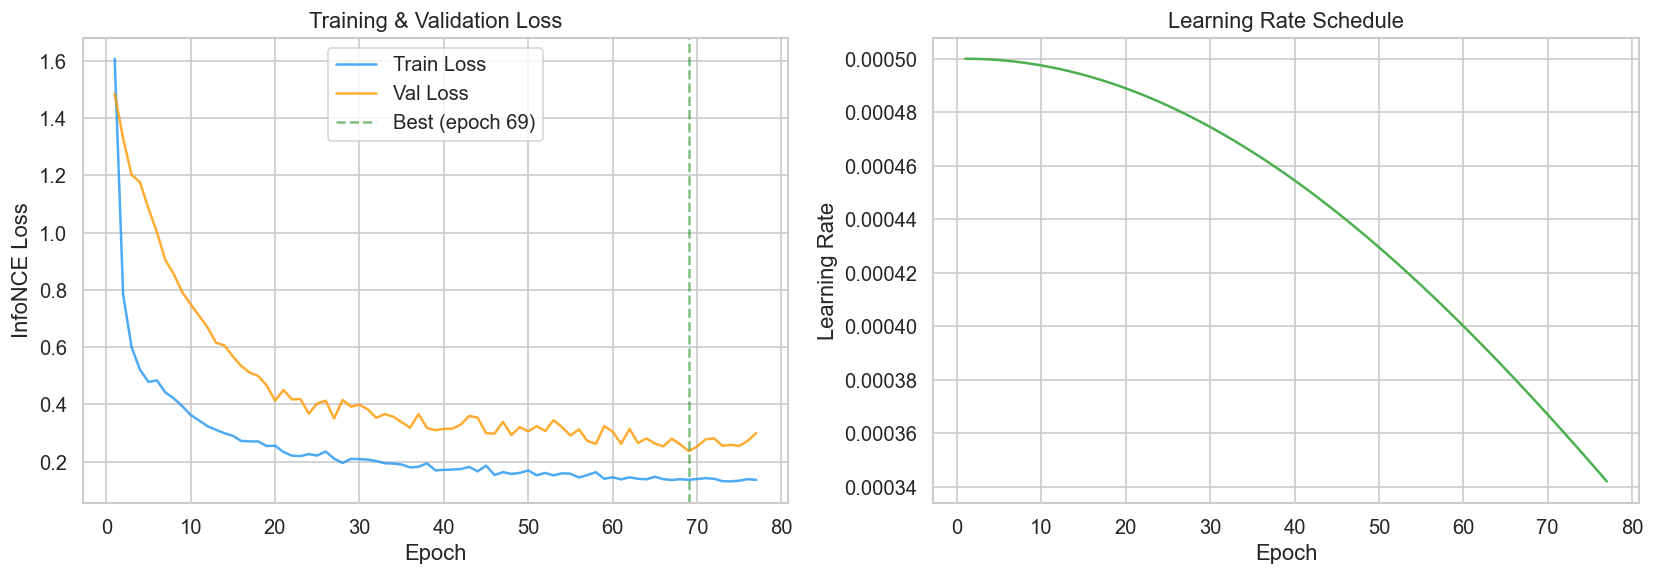

Final train loss:  0.1359
Final val loss:    0.2995
Best val loss:     0.2362 (epoch 69)
Total epochs:      77


In [149]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
epochs_range = range(1, len(train_losses) + 1)
axes[0].plot(epochs_range, train_losses, label='Train Loss', color='#2196F3', alpha=0.8)
axes[0].plot(epochs_range, val_losses, label='Val Loss', color='#FF9800', alpha=0.8)
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('InfoNCE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()

# Learning rate schedule
axes[1].plot(epochs_range, lr_history, color='#4CAF50')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')

plt.tight_layout()
plt.show()

# Final stats
print(f'Final train loss:  {train_losses[-1]:.4f}')
print(f'Final val loss:    {val_losses[-1]:.4f}')
print(f'Best val loss:     {best_val_loss:.4f} (epoch {best_epoch})')
print(f'Total epochs:      {len(train_losses)}')

---
## 7. Embedding Analysis

Load the best model and generate final embeddings, then visualise with t-SNE.

In [150]:
# Load best model
ckpt_obj = torch.load(ckpt_path, map_location=device)
if isinstance(ckpt_obj, dict) and 'state_dict' in ckpt_obj:
    ckpt = ckpt_obj['state_dict']
else:
    ckpt = ckpt_obj

model.load_state_dict(ckpt)
model.eval()

# Generate final embeddings
with torch.no_grad():
    x = data.x.to(device)
    all_edges = data.edge_index.to(device)
    gnn_embeddings = model(x, all_edges).cpu().numpy()

# Keep embeddings and metadata aligned
if len(nodes_df) != len(gnn_embeddings):
    n = min(len(nodes_df), len(gnn_embeddings))
    print(f'⚠️  Embedding/metadata size mismatch: nodes_df={len(nodes_df)}, embeddings={len(gnn_embeddings)}; trimming to {n}.')
    nodes_df = nodes_df.iloc[:n].reset_index(drop=True)
    gnn_embeddings = gnn_embeddings[:n]

print(f'GNN embeddings shape: {gnn_embeddings.shape}')
print(f'L2 norm (should be ~1.0): {np.linalg.norm(gnn_embeddings, axis=1).mean():.4f}')


GNN embeddings shape: (974, 768)
L2 norm (should be ~1.0): 1.0000


In [151]:
# Interactive 3D t-SNE visualisation coloured by node type
import plotly.express as px

print('Running t-SNE (this may take a moment)...')
perp = min(30, max(2, len(gnn_embeddings) - 1))
tsne = TSNE(n_components=3, perplexity=perp, random_state=42, max_iter=1000)
emb_3d = tsne.fit_transform(gnn_embeddings)

plot_df = pd.DataFrame({
    'tsne_1': emb_3d[:, 0],
    'tsne_2': emb_3d[:, 1],
    'tsne_3': emb_3d[:, 2],
    'type': nodes_df['type'].astype(str).values,
    'node_id': nodes_df['node_id'].astype(str).values,
    'title': nodes_df.get('title', pd.Series([''] * len(nodes_df))).fillna('').astype(str).values,
})
plot_df['hover'] = plot_df['node_id'] + ' | ' + plot_df['type'] + '<br>' + plot_df['title'].str[:120]

color_map = {
    'article': '#E53935',
    'paragraph': '#1E88E5',
    'recital': '#43A047',
    'definition': '#FB8C00',
    'annex': '#8E24AA',
    'annex_item': '#00ACC1',
}

fig = px.scatter_3d(
    plot_df,
    x='tsne_1',
    y='tsne_2',
    z='tsne_3',
    color='type',
    color_discrete_map=color_map,
    hover_name='node_id',
    hover_data={
        'tsne_1': False,
        'tsne_2': False,
        'tsne_3': False,
        'type': True,
        'title': True,
    },
    title='Interactive 3D t-SNE of GNN Node Embeddings by Type',
)
fig.update_traces(marker=dict(size=3, opacity=0.75))
fig.update_layout(
    width=1000,
    height=800,
    legend_title_text='Node Type',
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3',
    ),
)
fig.show()


Running t-SNE (this may take a moment)...


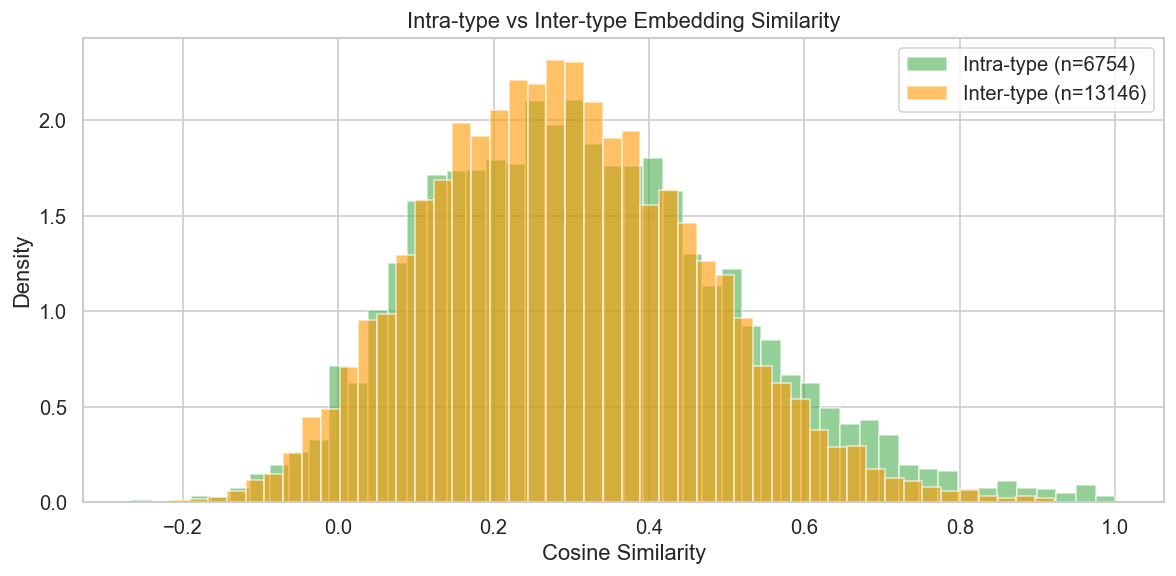

Mean intra-type similarity: 0.3138
Mean inter-type similarity: 0.2916
Difference:                 0.0222


In [152]:
# Embedding similarity within vs across node types
type_list = nodes_df['type'].values
intra_sims = []
inter_sims = []

np.random.seed(42)
sample_size = 200
idx_sample = np.random.choice(len(gnn_embeddings), min(sample_size, len(gnn_embeddings)), replace=False)

emb_sample = gnn_embeddings[idx_sample]
types_sample = type_list[idx_sample]
sim_matrix = cosine_similarity(emb_sample)

for i in range(len(idx_sample)):
    for j in range(i + 1, len(idx_sample)):
        if types_sample[i] == types_sample[j]:
            intra_sims.append(sim_matrix[i, j])
        else:
            inter_sims.append(sim_matrix[i, j])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(intra_sims, bins=50, alpha=0.6, label=f'Intra-type (n={len(intra_sims)})', color='#4CAF50', density=True)
ax.hist(inter_sims, bins=50, alpha=0.6, label=f'Inter-type (n={len(inter_sims)})', color='#FF9800', density=True)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title('Intra-type vs Inter-type Embedding Similarity')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean intra-type similarity: {np.mean(intra_sims):.4f}')
print(f'Mean inter-type similarity: {np.mean(inter_sims):.4f}')
print(f'Difference:                 {np.mean(intra_sims) - np.mean(inter_sims):.4f}')


---
## 8. Nearest-Neighbour Retrieval Demo

Show the top-k most similar nodes for selected query nodes to sanity-check the embeddings.

In [153]:
def find_nearest_neighbours(query_node_id, embeddings, nodes_df, top_k=10):
    """Find most similar nodes to a query node id with flexible id matching."""
    node_ids = nodes_df['node_id'].astype(str).values
    query = str(query_node_id)
    query_norm = query.replace('_', ' ').lower()

    candidates = []
    exact = [i for i, nid in enumerate(node_ids) if nid == query]
    if exact:
        candidates = exact

    if not candidates:
        exact_ci = [i for i, nid in enumerate(node_ids) if str(nid).lower() == query_norm.lower()]
        if exact_ci:
            candidates = exact_ci

    if not candidates:
        contains = [i for i, nid in enumerate(node_ids) if query_norm in str(nid).lower().replace('_', ' ')]
        candidates = contains

    if not candidates:
        all_ids = ', '.join(node_ids[:20])
        raise KeyError(f"Could not find node_id '{query}'. Example IDs: {all_ids}")

    idx = candidates[0]

    query_emb = embeddings[idx:idx + 1]
    sims = cosine_similarity(query_emb, embeddings)[0]

    # Exclude self
    sims[idx] = -1

    top_indices = np.argsort(sims)[::-1][:top_k]

    results = []
    for rank, i in enumerate(top_indices, 1):
        row = nodes_df.iloc[int(i)]
        results.append({
            'rank': rank,
            'node_id': row['node_id'],
            'type': row.get('type', 'unknown'),
            'title': row.get('title', ''),
            'similarity': sims[int(i)],
        })

    return pd.DataFrame(results)


In [154]:
# Query: Article 6 (High-Risk AI Systems)
print('═' * 70)
print('Query: Article 6 — Classification Rules for High-Risk AI Systems')
print('═' * 70)
find_nearest_neighbours('Article 6', gnn_embeddings, nodes_df, top_k=10)


══════════════════════════════════════════════════════════════════════
Query: Article 6 — Classification Rules for High-Risk AI Systems
══════════════════════════════════════════════════════════════════════


,rank,node_id,type,title,similarity
0,1,article_6_para_1,paragraph,"Article 6, Paragraph 1",0.904668
1,2,article_7,article,Article 7: Amendments to Annex III,0.849582
2,3,article_6_para_5,paragraph,"Article 6, Paragraph 5",0.849480
3,4,article_6_para_8,paragraph,"Article 6, Paragraph 8",0.835783
4,5,article_7_para_1,paragraph,"Article 7, Paragraph 1",0.834405
5,6,article_6_para_2,paragraph,"Article 6, Paragraph 2",0.822714
6,7,article_6_para_7,paragraph,"Article 6, Paragraph 7",0.821779
7,8,article_6_para_4,paragraph,"Article 6, Paragraph 4",0.810489
8,9,article_6_para_3,paragraph,"Article 6, Paragraph 3",0.804406
9,10,article_111,article,Article 111: AI systems already placed on the ...,0.781729


In [155]:
# Query: Article 5 (Prohibited AI Systems)
print('═' * 70)
print('Query: Article 5 — Prohibited AI Practices')
print('═' * 70)
find_nearest_neighbours('Article 5', gnn_embeddings, nodes_df, top_k=10)


══════════════════════════════════════════════════════════════════════
Query: Article 5 — Prohibited AI Practices
══════════════════════════════════════════════════════════════════════


,rank,node_id,type,title,similarity
0,1,article_5_para_1,paragraph,"Article 5, Paragraph 1",0.847535
1,2,annex_II,annex,Annex II: List of criminal offences referred t...,0.847061
2,3,definition_46,definition,Definition: law enforcement,0.840164
3,4,article_50,article,Article 50: Transparency obligations for provi...,0.830760
4,5,article_5_para_8,paragraph,"Article 5, Paragraph 8",0.827233
5,6,article_5_para_5,paragraph,"Article 5, Paragraph 5",0.825582
6,7,definition_52,definition,Definition: profiling,0.813680
7,8,article_5_para_3,paragraph,"Article 5, Paragraph 3",0.811870
8,9,article_5_para_6,paragraph,"Article 5, Paragraph 6",0.809101
9,10,article_5_para_4,paragraph,"Article 5, Paragraph 4",0.806379


---
## 9. Baseline Comparison

Compare GNN embeddings vs the raw sentence-transformer embeddings (no graph structure).

In [156]:
# Load raw text embeddings (without GNN)
raw_candidates = [
    Path(f"../{config['paths']['node_features']}"),
    Path(config['paths']['node_features']),
    Path('..') / config['paths']['node_features'],
]
raw_feature_path = next((p for p in raw_candidates if p.exists()), None)
if raw_feature_path is None:
    raise FileNotFoundError(f"Raw node features not found. Tried: {[str(p) for p in raw_candidates]}")

raw_features = np.load(raw_feature_path)
# Use the full encoder output width.
raw_text_emb = raw_features
# Normalise
raw_text_emb = raw_text_emb / (np.linalg.norm(raw_text_emb, axis=1, keepdims=True) + 1e-8)

if len(raw_text_emb) != len(gnn_embeddings):
    n = min(len(raw_text_emb), len(gnn_embeddings))
    raw_text_emb = raw_text_emb[:n]
    print(f'⚠️  Truncated raw text embeddings to {n} to match GNN embeddings')

print(f'Raw text embeddings shape:  {raw_text_emb.shape}')
print(f'GNN embeddings shape:       {gnn_embeddings.shape}')


Raw text embeddings shape:  (974, 775)
GNN embeddings shape:       (974, 768)


In [157]:
# Compare: which of Article 6's graph neighbours are ranked higher by GNN vs raw?
query = 'Article 6'

print('── GNN Embeddings: Top 10 for Article 6 ──')
gnn_nn = find_nearest_neighbours(query, gnn_embeddings, nodes_df, top_k=10)
print(gnn_nn.to_string(index=False))

print('\n── Raw Text Embeddings: Top 10 for Article 6 ──')
raw_nn = find_nearest_neighbours(query, raw_text_emb, nodes_df, top_k=10)
print(raw_nn.to_string(index=False))

── GNN Embeddings: Top 10 for Article 6 ──
 rank          node_id      type                                                                                                                        title  similarity
    1 article_6_para_1 paragraph                                                                                                       Article 6, Paragraph 1    0.904668
    2        article_7   article                                                                                           Article 7: Amendments to Annex III    0.849582
    3 article_6_para_5 paragraph                                                                                                       Article 6, Paragraph 5    0.849480
    4 article_6_para_8 paragraph                                                                                                       Article 6, Paragraph 8    0.835783
    5 article_7_para_1 paragraph                                                                           

Average cosine similarity between connected nodes:
  GNN embeddings:       0.7653 ± 0.1104
  Raw text embeddings:  0.2992 ± 0.1806
  Improvement:          +0.4662


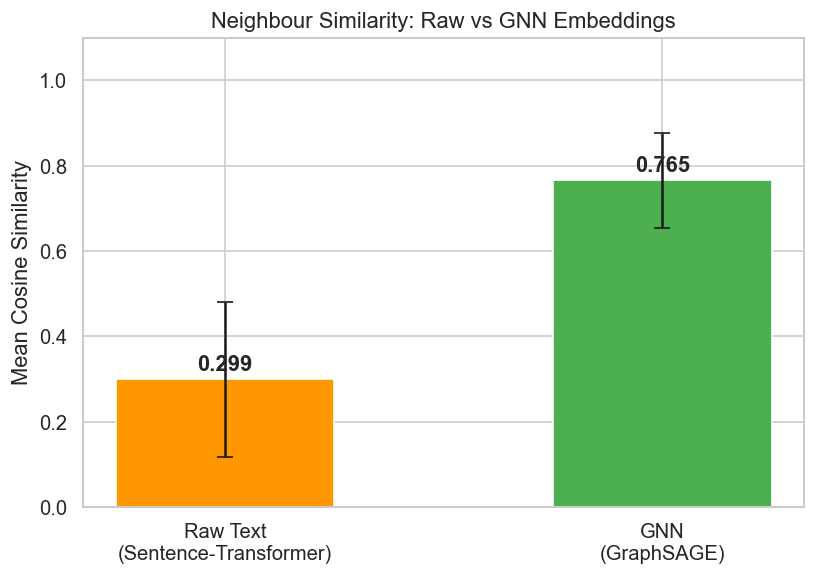

In [158]:
# Quantitative comparison: average similarity to graph neighbours


def avg_neighbour_similarity(embeddings, edge_index, num_nodes, sample_n=500):
    """Average cosine similarity between connected nodes."""
    if embeddings is None or len(embeddings) == 0:
        return float('nan'), float('nan')

    if edge_index is None or edge_index.dim() != 2 or edge_index.size(0) != 2:
        return float('nan'), float('nan')

    n_edges = int(edge_index.size(1))
    if n_edges == 0:
        return float('nan'), float('nan')

    sample_n = int(min(sample_n, n_edges))
    if sample_n <= 0:
        return float('nan'), float('nan')

    sample_idx = torch.randperm(n_edges, device=edge_index.device)[:sample_n]

    sims = []
    for idx in sample_idx:
        src = int(edge_index[0, idx].item())
        tgt = int(edge_index[1, idx].item())

        if src >= len(embeddings) or tgt >= len(embeddings):
            continue

        sim = cosine_similarity(embeddings[src:src + 1], embeddings[tgt:tgt + 1])[0, 0]
        sims.append(float(sim))

    if len(sims) == 0:
        return float('nan'), float('nan')

    return float(np.mean(sims)), float(np.std(sims))


gnn_mean, gnn_std = avg_neighbour_similarity(gnn_embeddings, data.edge_index, data.num_nodes)
raw_mean, raw_std = avg_neighbour_similarity(raw_text_emb, data.edge_index, data.num_nodes)

print(f'Average cosine similarity between connected nodes:')
print(f'  GNN embeddings:       {gnn_mean:.4f} ± {gnn_std:.4f}')
print(f'  Raw text embeddings:  {raw_mean:.4f} ± {raw_std:.4f}')

if np.isnan(gnn_mean) or np.isnan(raw_mean):
    print('⚠️  Not enough edges to compute neighbour similarity on this graph. Skipping plot.')
else:
    print(f'  Improvement:          {gnn_mean - raw_mean:+.4f}')

    # Bar chart
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(
        ['Raw Text\n(Sentence-Transformer)', 'GNN\n(GraphSAGE)'],
        [raw_mean, gnn_mean],
        yerr=[raw_std, gnn_std],
        color=['#FF9800', '#4CAF50'],
        capsize=5,
        width=0.5
    )
    ax.set_ylabel('Mean Cosine Similarity')
    ax.set_title('Neighbour Similarity: Raw vs GNN Embeddings')
    for bar, val in zip(bars, [raw_mean, gnn_mean]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontweight='bold')
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.show()


---
## 10. Save Final Embeddings

In [159]:
# Save GNN embeddings
emb_path = Path(f"../{config['paths']['gnn_embeddings']}")
emb_path.parent.mkdir(parents=True, exist_ok=True)
np.save(str(emb_path), gnn_embeddings)

print(f'✓ Saved GNN embeddings ({gnn_embeddings.shape}) to: {emb_path}')


✓ Saved GNN embeddings ((974, 768)) to: ../models/embeddings/gnn_node_embeddings_768.npy


---
## Summary

| Item | Value |
|------|-------|
| **Architecture** | GraphSAGE (2-layer, mean aggregation) |
| **Training** | Self-supervised contrastive (InfoNCE) |
| **Input features** | Sentence-Transformer embeddings (768d) + metadata (7d) = 775d |
| **Output embeddings** | 768-dimensional, L2-normalised |
| **Graph** | 974 nodes, 3873 edges, 4 edge types |

### Key Takeaways

1. **Convergence**: The model converges within the patience window, with loss curves showing smooth descent.
2. **Structure-aware embeddings**: t-SNE shows meaningful clustering — nodes of the same type and chapter group together.
3. **GNN vs Raw**: GNN embeddings produce higher cosine similarity between connected nodes, showing the model has learned to encode graph structure.
4. **Retrieval quality**: Nearest-neighbour queries return semantically and structurally related nodes, validating the embeddings for downstream retrieval.